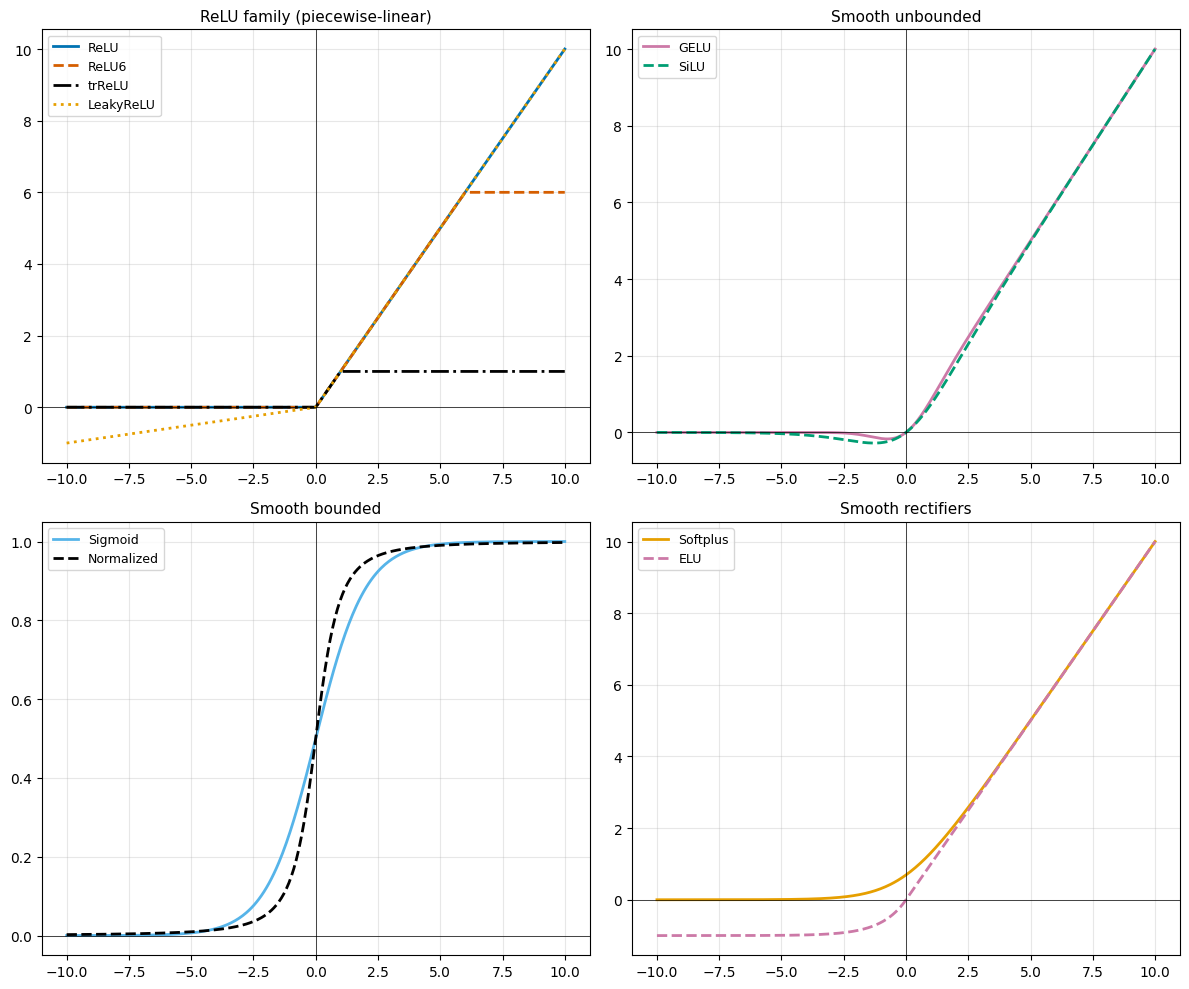

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Input range
x = torch.linspace(-10, 10, 400)

# Normalized activation (0,1)
def normalized(x):
    return (1.0 + x / torch.sqrt(1.0 + x * x)) / 2.0

# Okabe-Ito colorblind-safe palette
cb_colors = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
    "black": "#000000",
    "skyblue": "#56B4E9",
}

# Grouped activations
groups = {
    "ReLU family (piecewise-linear)": [
        ("ReLU", nn.ReLU(), cb_colors["blue"], "-"),
        ("ReLU6", nn.ReLU6(), cb_colors["red"], "--"),
        ("trReLU", nn.Hardtanh(0, 1), cb_colors["black"], "-."),
        ("LeakyReLU", nn.LeakyReLU(0.1), cb_colors["orange"], ":"),
    ],
    "Smooth unbounded": [
        ("GELU", nn.GELU(), cb_colors["purple"], "-"),
        ("SiLU", nn.SiLU(), cb_colors["green"], "--"),
    ],
    "Smooth bounded": [
        ("Sigmoid", nn.Sigmoid(), cb_colors["skyblue"], "-"),
        ("Normalized", normalized, cb_colors["black"], "--"),
    ],
    "Smooth rectifiers": [
        ("Softplus", nn.Softplus(), cb_colors["orange"], "-"),
        ("ELU", nn.ELU(), cb_colors["purple"], "--"),
    ],
}

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each group
for ax, (title, acts) in zip(axes, groups.items()):
    for name, func, color, linestyle in acts:
        y = func(x)
        if isinstance(y, torch.Tensor):
            y = y.detach().numpy()
        ax.plot(
            x.numpy(),
            y,
            label=name,
            color=color,
            linestyle=linestyle,
            linewidth=2
        )
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("activation_families_colorblind.png", dpi=300)
plt.show()